### Movie Recommender System
#### End-to-End Machine Learning Project

---

**Goal:** Build a complete recommender system using the MovieLens dataset — the same core technology used by Netflix, Spotify, and Amazon.

**Three approaches:**

| Approach | Technique | Real-world example |
|---|---|---|
| Collaborative Filtering | User-based & Item-based cosine similarity | Amazon "customers also bought" |
| Matrix Factorisation | SVD (Singular Value Decomposition) | Netflix Prize winner |
| Content-Based Filtering | TF-IDF on genres | Pandora music genome |

Covers three paradigms, matrix algebra, NLP, proper evaluation metrics, and mirrors real industry systems.


####  Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

BLUE, ORANGE, GREEN, RED, PURPLE = '#2E86AB','#F4A261','#2DC653','#E84855','#9B59B6'
print("All libraries loaded successfully.")


All libraries loaded successfully.


---
####  Dataset — MovieLens Style

We replicate the **MovieLens 100K** benchmark schema:
- `ratings` — user_id, movie_id, rating (1-5)
- `movies`  — movie_id, title, genres

> To use the real MovieLens dataset, replace the synthetic block with:
> `ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=['user_id','movie_id','rating','timestamp'])`
> Download free from: https://grouplens.org/datasets/movielens/100k/


In [2]:
np.random.seed(42)

# Movie catalogue
movies_data = [
    (1,  "Toy Story (1995)",              "Animation|Children|Comedy"),
    (2,  "GoldenEye (1995)",              "Action|Adventure|Thriller"),
    (3,  "Four Rooms (1995)",             "Thriller"),
    (4,  "Get Shorty (1995)",             "Action|Comedy|Drama"),
    (5,  "Copycat (1995)",                "Crime|Drama|Thriller"),
    (6,  "Twelve Monkeys (1995)",         "Drama|Sci-Fi"),
    (7,  "Babe (1995)",                   "Children|Comedy|Drama"),
    (8,  "Seven (1995)",                  "Crime|Mystery|Thriller"),
    (9,  "Usual Suspects, The (1995)",    "Crime|Mystery|Thriller"),
    (10, "Sense and Sensibility (1995)",  "Drama|Romance"),
    (11, "Ace Ventura (1994)",            "Comedy"),
    (12, "Pulp Fiction (1994)",           "Crime|Drama|Thriller"),
    (13, "Shawshank Redemption (1994)",   "Crime|Drama"),
    (14, "Silence of the Lambs (1991)",  "Crime|Horror|Thriller"),
    (15, "Schindlers List (1993)",        "Drama|War"),
    (16, "Forrest Gump (1994)",           "Comedy|Drama|Romance|War"),
    (17, "Lion King, The (1994)",         "Animation|Children|Musical"),
    (18, "Star Wars (1977)",              "Action|Adventure|Sci-Fi"),
    (19, "Fargo (1996)",                  "Crime|Drama|Thriller"),
    (20, "Braveheart (1995)",             "Action|Drama|War"),
    (21, "Jurassic Park (1993)",          "Action|Adventure|Sci-Fi|Thriller"),
    (22, "The Matrix (1999)",             "Action|Sci-Fi|Thriller"),
    (23, "Fight Club (1999)",             "Crime|Drama|Thriller"),
    (24, "Goodfellas (1990)",             "Crime|Drama"),
    (25, "The Godfather (1972)",          "Crime|Drama"),
    (26, "Inception (2010)",              "Action|Sci-Fi|Thriller"),
    (27, "Interstellar (2014)",           "Drama|Sci-Fi"),
    (28, "The Dark Knight (2008)",        "Action|Crime|Drama|Thriller"),
    (29, "Titanic (1997)",                "Drama|Romance"),
    (30, "Gladiator (2000)",              "Action|Drama|War"),
    (31, "The Departed (2006)",           "Crime|Drama|Thriller"),
    (32, "Memento (2000)",                "Crime|Mystery|Thriller"),
    (33, "No Country for Old Men (2007)", "Crime|Drama|Thriller"),
    (34, "The Prestige (2006)",           "Drama|Mystery|Sci-Fi|Thriller"),
    (35, "Whiplash (2014)",               "Drama|Music"),
    (36, "La La Land (2016)",             "Comedy|Drama|Music|Romance"),
    (37, "Parasite (2019)",               "Crime|Drama|Thriller"),
    (38, "The Grand Budapest Hotel",      "Comedy|Crime|Drama"),
    (39, "Mad Max Fury Road (2015)",      "Action|Adventure|Sci-Fi"),
    (40, "Her (2013)",                    "Drama|Romance|Sci-Fi"),
    (41, "Get Out (2017)",                "Horror|Mystery|Thriller"),
    (42, "Home Alone (1990)",             "Children|Comedy"),
    (43, "Toy Story 2 (1999)",            "Animation|Children|Comedy"),
    (44, "Finding Nemo (2003)",           "Animation|Children|Comedy"),
    (45, "Up (2009)",                     "Animation|Children|Comedy|Drama"),
    (46, "WALL-E (2008)",                 "Animation|Children|Romance|Sci-Fi"),
    (47, "Coco (2017)",                   "Animation|Children|Comedy|Drama|Music"),
    (48, "The Revenant (2015)",           "Action|Adventure|Drama|Thriller"),
    (49, "1917 (2019)",                   "Action|Drama|War"),
    (50, "Joker (2019)",                  "Crime|Drama|Thriller"),
]
movies = pd.DataFrame(movies_data, columns=["movie_id","title","genres"])

# Simulate ratings with genre preferences
N_USERS, N_MOVIES, N_RATINGS = 200, len(movies), 3000
movie_quality   = np.random.uniform(2.5, 5.0, N_MOVIES)
genre_list      = ["Action","Adventure","Animation","Children","Comedy",
                   "Crime","Drama","Horror","Music","Musical","Mystery",
                   "Romance","Sci-Fi","Thriller","War"]
user_genre_pref = np.random.dirichlet(np.ones(len(genre_list)), N_USERS)

def genre_match(genres_str, user_prefs):
    genres = genres_str.split("|")
    idxs   = [genre_list.index(g) for g in genres if g in genre_list]
    return np.mean(user_prefs[idxs]) if idxs else 0.25

rows = []
uid_arr = np.random.choice(range(1, N_USERS+1), N_RATINGS, replace=True)
mid_arr = np.random.choice(movies["movie_id"].values, N_RATINGS, replace=True)
for uid, mid in zip(uid_arr, mid_arr):
    row      = movies[movies.movie_id == mid].iloc[0]
    quality  = movie_quality[mid - 1]
    match    = genre_match(row.genres, user_genre_pref[uid - 1])
    raw      = 0.5 * quality + 2.5 * match + np.random.normal(0, 0.6)
    rating   = np.clip(round(raw * 2) / 2, 1, 5)
    rows.append({"user_id": uid, "movie_id": mid, "rating": rating})

ratings = pd.DataFrame(rows).drop_duplicates(subset=["user_id","movie_id"])
TARGET_USER = 5

print(f"Movies   : {len(movies)}")
print(f"Users    : {ratings['user_id'].nunique()}")
print(f"Ratings  : {len(ratings):,}")
print(f"Sparsity : {1 - len(ratings)/(ratings.user_id.nunique()*len(movies)):.1%}")
ratings.head()


Movies   : 50
Users    : 200
Ratings  : 2,586
Sparsity : 74.1%


,user_id,movie_id,rating
0,10,1,2.5
1,98,49,1.5
2,89,25,2.5
3,35,10,2.0
4,2,16,1.5


---
#### Exploratory Data Analysis

Before modelling we understand the data — a step that separates good data scientists from great ones.

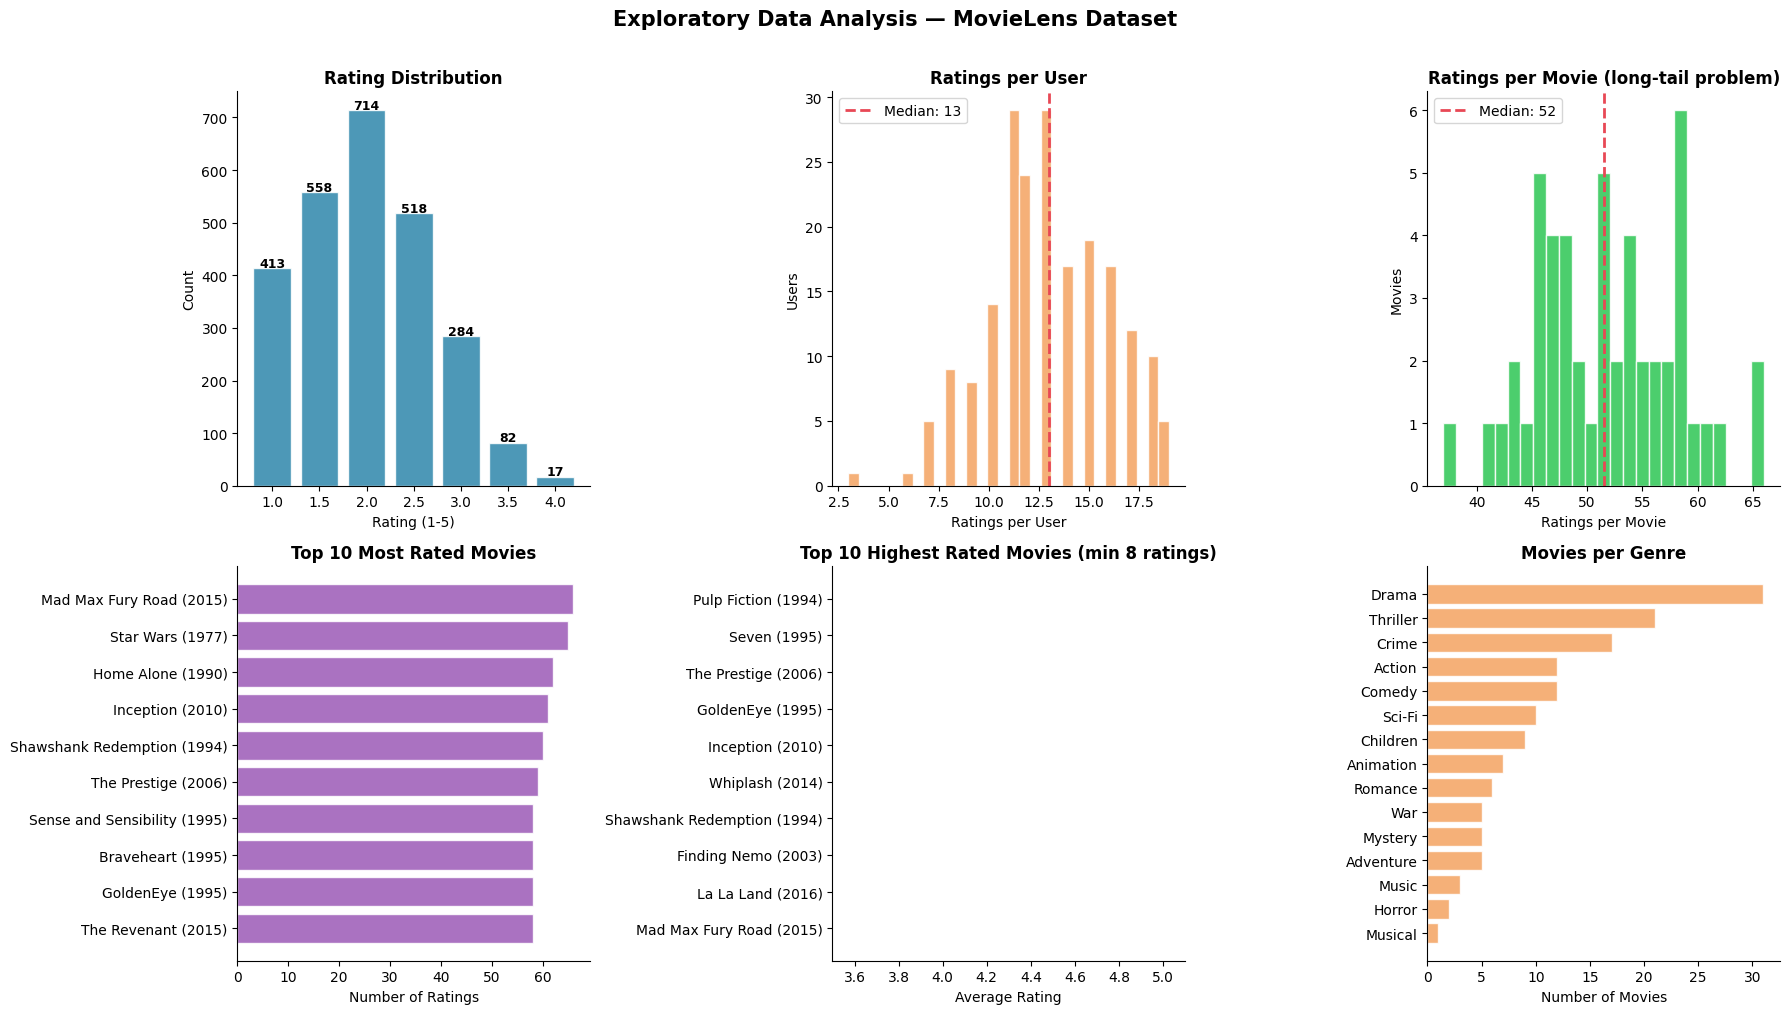

Avg ratings per user  : 12.9
Avg ratings per movie : 51.7


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ratings_per_user  = ratings.groupby("user_id").size()
ratings_per_movie = ratings.groupby("movie_id").size()

# Rating distribution
ax = axes[0,0]
rc = ratings["rating"].value_counts().sort_index()
ax.bar(rc.index, rc.values, width=0.4, color=BLUE, edgecolor="white", alpha=0.85)
ax.set_xlabel("Rating (1-5)"); ax.set_ylabel("Count")
ax.set_title("Rating Distribution", fontweight="bold")
for x, y in zip(rc.index, rc.values):
    ax.text(x, y+3, str(y), ha="center", fontsize=9, fontweight="bold")

# Ratings per user
ax = axes[0,1]
ax.hist(ratings_per_user, bins=30, color=ORANGE, edgecolor="white", alpha=0.85)
ax.axvline(ratings_per_user.median(), color=RED, lw=2, linestyle="--",
           label=f"Median: {ratings_per_user.median():.0f}")
ax.set_xlabel("Ratings per User"); ax.set_ylabel("Users")
ax.set_title("Ratings per User", fontweight="bold"); ax.legend()

# Ratings per movie
ax = axes[0,2]
ax.hist(ratings_per_movie, bins=25, color=GREEN, edgecolor="white", alpha=0.85)
ax.axvline(ratings_per_movie.median(), color=RED, lw=2, linestyle="--",
           label=f"Median: {ratings_per_movie.median():.0f}")
ax.set_xlabel("Ratings per Movie"); ax.set_ylabel("Movies")
ax.set_title("Ratings per Movie (long-tail problem)", fontweight="bold"); ax.legend()

# Top 10 most rated movies
ax = axes[1,0]
top_m = (ratings.groupby("movie_id").size().reset_index(name="n")
         .merge(movies[["movie_id","title"]], on="movie_id")
         .sort_values("n", ascending=False).head(10))
ax.barh(top_m["title"].str[:30][::-1], top_m["n"][::-1],
        color=PURPLE, edgecolor="white", alpha=0.85)
ax.set_xlabel("Number of Ratings")
ax.set_title("Top 10 Most Rated Movies", fontweight="bold")

# Top 10 highest rated (min 8 ratings)
ax = axes[1,1]
avg_r = (ratings.groupby("movie_id")["rating"].mean().reset_index(name="avg")
         .merge(ratings.groupby("movie_id").size().reset_index(name="n"), on="movie_id")
         .merge(movies[["movie_id","title"]], on="movie_id")
         .query("n >= 8").sort_values("avg", ascending=False).head(10))
ax.barh(avg_r["title"].str[:30][::-1], avg_r["avg"][::-1],
        color=BLUE, edgecolor="white", alpha=0.85)
ax.set_xlabel("Average Rating"); ax.set_xlim(3.5, 5.1)
ax.set_title("Top 10 Highest Rated Movies (min 8 ratings)", fontweight="bold")

# Genre popularity
ax = axes[1,2]
gc = {}
for g_str in movies["genres"]:
    for g in g_str.split("|"):
        gc[g] = gc.get(g, 0) + 1
genre_s = pd.Series(gc).sort_values(ascending=True)
ax.barh(genre_s.index, genre_s.values, color=ORANGE, edgecolor="white", alpha=0.85)
ax.set_xlabel("Number of Movies"); ax.set_title("Movies per Genre", fontweight="bold")

plt.suptitle("Exploratory Data Analysis — MovieLens Dataset",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/tmp/rs_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Avg ratings per user  : {ratings_per_user.mean():.1f}")
print(f"Avg ratings per movie : {ratings_per_movie.mean():.1f}")


---
#### User-Item Rating Matrix

The foundation of collaborative filtering. Rows = users, columns = movies, values = ratings. Most cells are empty (sparse).

> **Notes:** Real platforms have 99.9%+ sparsity. Netflix has ~200M users x ~15K titles. Sparse matrix formats (CSR) are essential — a dense matrix would not fit in RAM.


Matrix shape : (200, 50)  (users x movies)
Filled cells : 2,586
Empty cells  : 7,414
Sparsity     : 74.1%


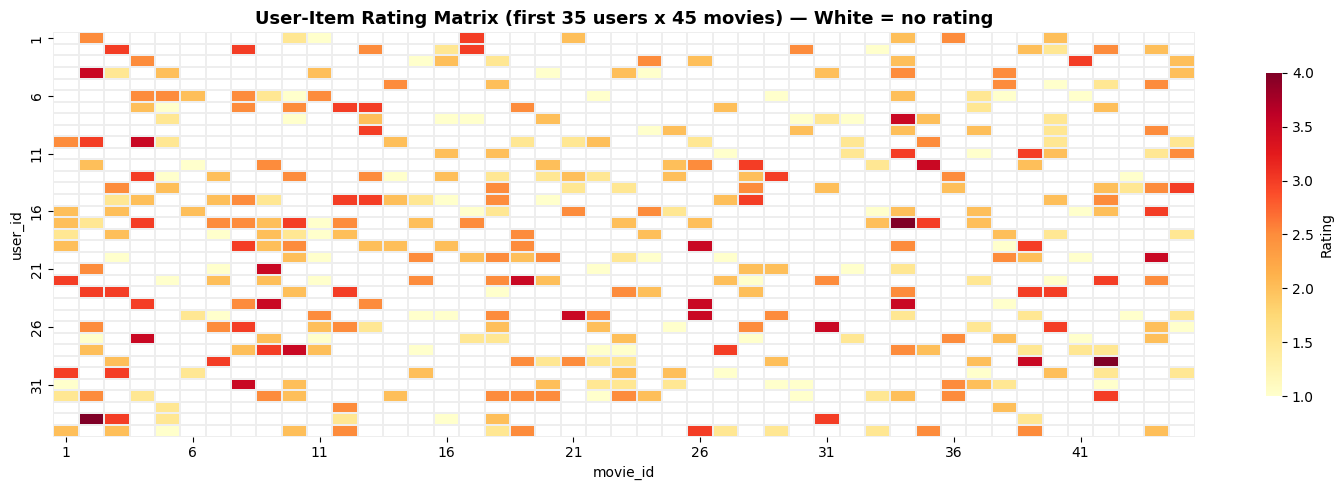

In [4]:
user_item_matrix = ratings.pivot_table(
    index="user_id", columns="movie_id", values="rating"
)
print(f"Matrix shape : {user_item_matrix.shape}  (users x movies)")
print(f"Filled cells : {user_item_matrix.notna().sum().sum():,}")
print(f"Empty cells  : {user_item_matrix.isna().sum().sum():,}")
print(f"Sparsity     : {user_item_matrix.isna().mean().mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(user_item_matrix.iloc[:35, :45], ax=ax,
            cmap="YlOrRd", linewidths=0.1, linecolor="#eee",
            cbar_kws={"label": "Rating", "shrink": 0.8},
            yticklabels=5, xticklabels=5)
ax.set_title("User-Item Rating Matrix (first 35 users x 45 movies) — White = no rating",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/rs_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


---
#### Approach 1 — Collaborative Filtering

Finds patterns in **who rates what** — no movie content needed.

- **User-based CF:** Find similar users, recommend what they liked
- **Item-based CF:** Find similar movies, recommend those

**Cosine Similarity:** sim(A,B) = (A·B) / (||A|| ||B||)

> **Interview tip:** Item-based CF (Amazon) is more stable than user-based because user preferences shift over time while item similarities are relatively static.


User similarity matrix : (200, 200)
Item similarity matrix : (50, 50)


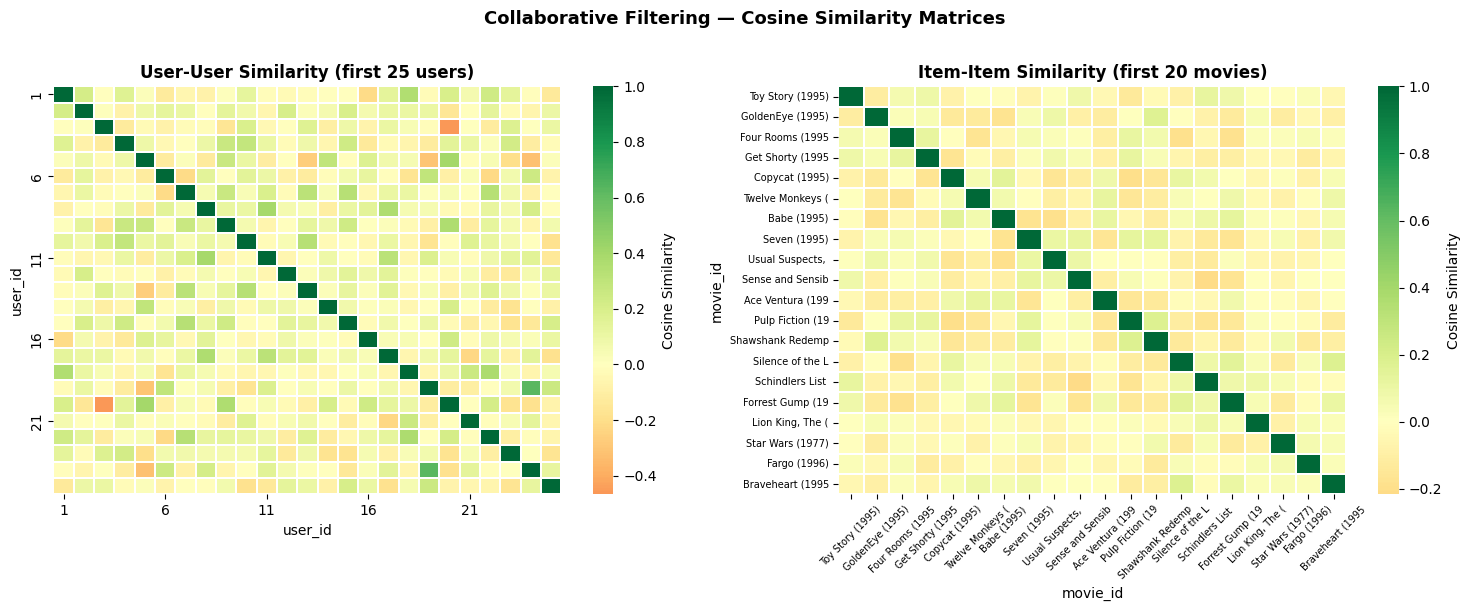

In [5]:
# Mean-centre ratings to remove user bias
# A harsh rater giving 3s shows same enthusiasm as a generous rater giving 5s
user_means  = user_item_matrix.mean(axis=1)
matrix_norm = user_item_matrix.sub(user_means, axis=0).fillna(0)

# User-User similarity
user_similarity = cosine_similarity(matrix_norm)
user_sim_df     = pd.DataFrame(user_similarity,
                               index=user_item_matrix.index,
                               columns=user_item_matrix.index)

# Item-Item similarity
item_similarity = cosine_similarity(matrix_norm.T)
item_sim_df     = pd.DataFrame(item_similarity,
                               index=user_item_matrix.columns,
                               columns=user_item_matrix.columns)

print(f"User similarity matrix : {user_sim_df.shape}")
print(f"Item similarity matrix : {item_sim_df.shape}")

# Visualise both matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(user_sim_df.iloc[:25, :25], ax=axes[0], cmap="RdYlGn", center=0,
            linewidths=0.1, cbar_kws={"label": "Cosine Similarity"},
            xticklabels=5, yticklabels=5)
axes[0].set_title("User-User Similarity (first 25 users)", fontweight="bold")

labels = [movies[movies.movie_id==mid]["title"].values[0][:16]
          for mid in item_sim_df.index[:20]]
sns.heatmap(item_sim_df.iloc[:20, :20], ax=axes[1], cmap="RdYlGn", center=0,
            linewidths=0.2, cbar_kws={"label": "Cosine Similarity"},
            xticklabels=labels, yticklabels=labels)
axes[1].set_title("Item-Item Similarity (first 20 movies)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1].tick_params(axis="y", labelsize=7)

plt.suptitle("Collaborative Filtering — Cosine Similarity Matrices",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/tmp/rs_similarity.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
def user_based_recommendations(user_id, n_recs=10, n_similar_users=20):
    """
    Recommend movies via user-based collaborative filtering.
    Steps:
      1. Find N most similar users
      2. Collect movies those users liked that the target user has NOT seen
      3. Score each unseen movie as weighted average rating from similar users
      4. Return top-N by score
    """
    sim_scores    = user_sim_df[user_id].drop(user_id).sort_values(ascending=False)
    top_users     = sim_scores.head(n_similar_users)
    rated_by_user = set(user_item_matrix.loc[user_id].dropna().index)

    scores = {}
    for movie_id in user_item_matrix.columns:
        if movie_id in rated_by_user:
            continue
        weighted_sum, sim_total = 0, 0
        for similar_user, sim in top_users.items():
            r = user_item_matrix.loc[similar_user, movie_id]
            if pd.notna(r) and sim > 0:
                weighted_sum += sim * r
                sim_total    += sim
        if sim_total > 0:
            scores[movie_id] = weighted_sum / sim_total

    if not scores:
        return pd.DataFrame()
    recs = pd.Series(scores).sort_values(ascending=False).head(n_recs).reset_index()
    recs.columns = ["movie_id", "predicted_rating"]
    return recs.merge(movies[["movie_id","title","genres"]], on="movie_id")


def item_based_recommendations(movie_title, n_recs=10):
    """Return movies most similar to a given movie based on rating patterns."""
    match = movies[movies["title"].str.contains(movie_title, case=False, na=False)]
    if match.empty:
        print(f"Not found: {movie_title}"); return pd.DataFrame()
    movie_id = match.iloc[0]["movie_id"]
    title    = match.iloc[0]["title"]
    sim_s    = item_sim_df[movie_id].drop(movie_id).sort_values(ascending=False).head(n_recs)
    recs     = sim_s.reset_index()
    recs.columns = ["movie_id", "similarity"]
    recs     = recs.merge(movies[["movie_id","title","genres"]], on="movie_id")
    print(f"=== Movies Similar to: {title} ===\n")
    print(recs[["title","genres","similarity"]].to_string(index=False))
    return recs


# 
user_recs = user_based_recommendations(TARGET_USER, n_recs=10)
print(f"=== User-Based CF — Recommendations for User {TARGET_USER} ===\n")
print(user_recs[["title","genres","predicted_rating"]].to_string(index=False))
print()
_ = item_based_recommendations("Matrix", n_recs=8)


=== User-Based CF — Recommendations for User 5 ===

                      title                          genres  predicted_rating
Shawshank Redemption (1994)                     Crime|Drama          3.160978
            Whiplash (2014)                     Drama|Music          3.000000
          Get Shorty (1995)             Action|Comedy|Drama          2.922572
        Pulp Fiction (1994)            Crime|Drama|Thriller          2.703175
                  Up (2009) Animation|Children|Comedy|Drama          2.647325
             Titanic (1997)                   Drama|Romance          2.614701
   Mad Max Fury Road (2015)         Action|Adventure|Sci-Fi          2.552948
 Usual Suspects, The (1995)          Crime|Mystery|Thriller          2.552725
        The Departed (2006)            Crime|Drama|Thriller          2.453108
               Seven (1995)          Crime|Mystery|Thriller          2.385323

=== Movies Similar to: The Matrix (1999) ===

                   title                   

---
#### Approach 2 — Matrix Factorisation (SVD)

SVD decomposes the rating matrix into latent factors:

**R ≈ U × Σ × Vᵀ**

- **U** (users × k): how much each user relates to each latent factor
- **Σ** (k × k): importance of each latent factor  
- **Vᵀ** (k × items): how much each movie relates to each latent factor

The k latent factors represent hidden concepts — preference for action, slow dramas, foreign films — learned automatically.

> **Notes:** This is essentially the algorithm that **won the Netflix Prize ($1M in 2009)**. Simon Funk's SVD blog post during the competition became legendary in the ML community.


Global mean rating : 2.003
SVD shapes:
  U  (users x k)   : (200, 20)
  Sigma diagonal   : (20, 20)
  Vt (k x movies)  : (20, 50)


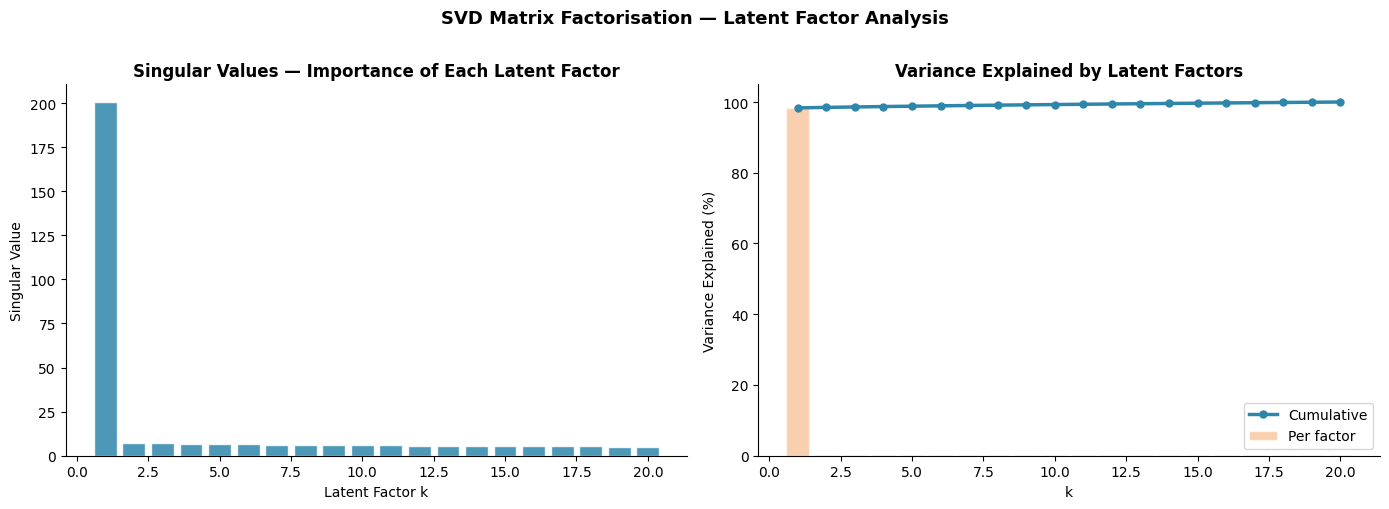

In [7]:
global_mean = ratings["rating"].mean()
matrix_svd  = user_item_matrix.fillna(global_mean).values
K = 20  # number of latent factors — tune this (try 10, 20, 50)

U, sigma, Vt = svds(csr_matrix(matrix_svd).astype(float), k=K)
sigma_diag   = np.diag(sigma)

print(f"Global mean rating : {global_mean:.3f}")
print(f"SVD shapes:")
print(f"  U  (users x k)   : {U.shape}")
print(f"  Sigma diagonal   : {sigma_diag.shape}")
print(f"  Vt (k x movies)  : {Vt.shape}")

# Visualise singular values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sv = sigma[::-1]  # svds returns ascending, flip to descending
axes[0].bar(range(1, K+1), sv, color=BLUE, edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Latent Factor k"); axes[0].set_ylabel("Singular Value")
axes[0].set_title("Singular Values — Importance of Each Latent Factor", fontweight="bold")

cum_var = np.cumsum(sv**2) / (sv**2).sum() * 100
axes[1].plot(range(1, K+1), cum_var, marker="o", color=BLUE, lw=2.5, markersize=5,
             label="Cumulative")
axes[1].bar(range(1, K+1), sv**2/(sv**2).sum()*100, color=ORANGE, alpha=0.5,
            edgecolor="white", label="Per factor")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Variance Explained (%)")
axes[1].set_title("Variance Explained by Latent Factors", fontweight="bold")
axes[1].legend()

plt.suptitle("SVD Matrix Factorisation — Latent Factor Analysis",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/tmp/rs_svd.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
# Reconstruct full predicted ratings matrix
predicted_ratings = np.dot(np.dot(U, sigma_diag), Vt)
predicted_df = pd.DataFrame(predicted_ratings,
                             index=user_item_matrix.index,
                             columns=user_item_matrix.columns)

print(f"Predicted matrix shape : {predicted_df.shape}")
print(f"Predicted rating range : {predicted_df.values.min():.2f} — {predicted_df.values.max():.2f}")


def svd_recommendations(user_id, n_recs=10):
    """Recommend unrated movies using SVD predicted ratings."""
    rated_by_user = set(user_item_matrix.loc[user_id].dropna().index)
    recs = (predicted_df.loc[user_id]
            .drop(index=list(rated_by_user), errors="ignore")
            .sort_values(ascending=False)
            .head(n_recs)
            .reset_index())
    recs.columns = ["movie_id", "predicted_rating"]
    return recs.merge(movies[["movie_id","title","genres"]], on="movie_id")


svd_recs = svd_recommendations(TARGET_USER, n_recs=10)
print(f"\n=== SVD Recommendations for User {TARGET_USER} ===\n")
print(svd_recs[["title","genres","predicted_rating"]].to_string(index=False))


Predicted matrix shape : (200, 50)
Predicted rating range : 0.85 — 3.84

=== SVD Recommendations for User 5 ===

                       title                           genres  predicted_rating
    Mad Max Fury Road (2015)          Action|Adventure|Sci-Fi          2.247444
         Forrest Gump (1994)         Comedy|Drama|Romance|War          2.168604
        The Godfather (1972)                      Crime|Drama          2.168523
              Copycat (1995)             Crime|Drama|Thriller          2.108718
         The Departed (2006)             Crime|Drama|Thriller          2.105107
           Braveheart (1995)                 Action|Drama|War          2.099308
  Usual Suspects, The (1995)           Crime|Mystery|Thriller          2.092476
Sense and Sensibility (1995)                    Drama|Romance          2.087249
        Jurassic Park (1993) Action|Adventure|Sci-Fi|Thriller          2.080238
         Pulp Fiction (1994)             Crime|Drama|Thriller          2.058338


---
#### Approach 3 — Content-Based Filtering

Recommends movies similar to what the user already liked, based on **movie metadata** (genres) — no other user data needed.

**Pipeline:** genres -> TF-IDF vectors -> cosine similarity -> rank unseen movies

> **Notes:** Content-based solves the **cold-start problem for new movies**. A brand-new film with zero ratings can still be recommended if its genres match what a user likes. Collaborative filtering cannot do this.


In [9]:
movies["genre_str"] = movies["genres"].str.replace("|", " ", regex=False)

tfidf        = TfidfVectorizer(token_pattern=r"[A-Za-z-]+")
genre_matrix = tfidf.fit_transform(movies["genre_str"])
content_sim  = cosine_similarity(genre_matrix)
content_sim_df = pd.DataFrame(content_sim,
                               index=movies["movie_id"],
                               columns=movies["movie_id"])

print(f"Genre vocabulary   : {len(tfidf.vocabulary_)} terms")
print(f"Content sim matrix : {content_sim_df.shape}")
print(f"Vocabulary         : {list(tfidf.vocabulary_.keys())}")


def content_based_recommendations(movie_title, n_recs=10):
    """Return movies with most similar genres to the input movie."""
    match = movies[movies["title"].str.contains(movie_title, case=False, na=False)]
    if match.empty:
        print(f"Not found: {movie_title}"); return pd.DataFrame()
    movie_id = match.iloc[0]["movie_id"]
    title    = match.iloc[0]["title"]
    sim_s    = content_sim_df[movie_id].drop(movie_id).sort_values(ascending=False).head(n_recs)
    recs     = sim_s.reset_index()
    recs.columns = ["movie_id","content_similarity"]
    recs     = recs.merge(movies[["movie_id","title","genres"]], on="movie_id")
    print(f"=== Content-Based: Similar to '{title}' ===")
    print(f"    Source genres: {match.iloc[0].genres}\n")
    print(recs[["title","genres","content_similarity"]].to_string(index=False))
    return recs


def content_based_for_user(user_id, n_recs=10, min_rating=4.0):
    """Build a user profile from highly-rated movies, then find similar unseen movies."""
    liked = (user_item_matrix.loc[user_id].dropna()
             .where(lambda x: x >= min_rating).dropna())
    if liked.empty:
        print("No highly rated movies found."); return pd.DataFrame()

    liked_ids    = liked.index.tolist()
    sim_to_liked = content_sim_df[liked_ids].mean(axis=1)
    rated_ids    = user_item_matrix.loc[user_id].dropna().index.tolist()
    sim_to_liked = sim_to_liked.drop(rated_ids, errors="ignore")

    recs = sim_to_liked.sort_values(ascending=False).head(n_recs).reset_index()
    recs.columns = ["movie_id","content_score"]
    recs = recs.merge(movies[["movie_id","title","genres"]], on="movie_id")
    liked_titles = movies[movies.movie_id.isin(liked_ids)]["title"].tolist()
    print(f"User {user_id} liked: {liked_titles[:3]} ...")
    print(recs[["title","genres","content_score"]].to_string(index=False))
    return recs


_ = content_based_recommendations("Matrix", n_recs=8)
print()
cb_user_recs = content_based_for_user(TARGET_USER, n_recs=8)


Genre vocabulary   : 15 terms
Content sim matrix : (50, 50)
Vocabulary         : ['animation', 'children', 'comedy', 'action', 'adventure', 'thriller', 'drama', 'crime', 'sci-fi', 'mystery', 'romance', 'horror', 'war', 'musical', 'music']
=== Content-Based: Similar to 'The Matrix (1999)' ===
    Source genres: Action|Sci-Fi|Thriller

                   title                           genres  content_similarity
        Inception (2010)           Action|Sci-Fi|Thriller            1.000000
    Jurassic Park (1993) Action|Adventure|Sci-Fi|Thriller            0.780919
        Star Wars (1977)          Action|Adventure|Sci-Fi            0.654690
Mad Max Fury Road (2015)          Action|Adventure|Sci-Fi            0.654690
  The Dark Knight (2008)      Action|Crime|Drama|Thriller            0.585348
   Twelve Monkeys (1995)                     Drama|Sci-Fi            0.558692
     Interstellar (2014)                     Drama|Sci-Fi            0.558692
     The Prestige (2006)    Drama|Myster

---
#### Hybrid Recommender (Best of All Worlds)

Real systems (Netflix, Spotify, YouTube) combine multiple signals:

**hybrid_score = α × SVD_score + (1−α) × content_score**

Higher α = more collaborative filtering. Lower α = more content-based.

> **Notes:** Hybrid systems are the industry standard. Pure CF suffers from cold-start. Pure content-based suffers from over-specialisation (only recommending very similar things). Hybrids balance both weaknesses.


In [10]:
def hybrid_recommendations(user_id, n_recs=10, alpha=0.7):
    """
    Blend SVD (collaborative) and content-based scores.
    alpha: weight for SVD signal (1-alpha = content weight).
    """
    rated_by_user = set(user_item_matrix.loc[user_id].dropna().index)
    liked_ids     = (user_item_matrix.loc[user_id].dropna()
                     .where(lambda x: x >= 3.5).dropna().index.tolist())

    results = []
    for movie_id in movies["movie_id"]:
        if movie_id in rated_by_user:
            continue
        svd_score     = predicted_df.loc[user_id, movie_id]
        content_score = (content_sim_df.loc[movie_id, liked_ids].mean()
                         if liked_ids else 0.5)
        results.append({"movie_id": movie_id,
                        "svd_score": svd_score,
                        "content_score": content_score})

    res_df = pd.DataFrame(results)
    scaler = MinMaxScaler()
    res_df[["svd_norm","content_norm"]] = scaler.fit_transform(
        res_df[["svd_score","content_score"]]
    )
    res_df["hybrid_score"] = (alpha * res_df["svd_norm"] +
                               (1 - alpha) * res_df["content_norm"])

    recs = (res_df.sort_values("hybrid_score", ascending=False)
            .head(n_recs)
            .merge(movies[["movie_id","title","genres"]], on="movie_id"))
    return recs


hybrid_recs = hybrid_recommendations(TARGET_USER, n_recs=10, alpha=0.7)
print(f"=== Hybrid Recommendations for User {TARGET_USER} ===\n")
print(hybrid_recs[["title","genres","hybrid_score","svd_norm","content_norm"]]
      .round(3).to_string(index=False))


=== Hybrid Recommendations for User 5 ===

                       title                           genres  hybrid_score  svd_norm  content_norm
    Mad Max Fury Road (2015)          Action|Adventure|Sci-Fi         0.700     1.000           0.0
         Forrest Gump (1994)         Comedy|Drama|Romance|War         0.593     0.847           0.0
        The Godfather (1972)                      Crime|Drama         0.593     0.847           0.0
              Copycat (1995)             Crime|Drama|Thriller         0.511     0.730           0.0
         The Departed (2006)             Crime|Drama|Thriller         0.506     0.723           0.0
           Braveheart (1995)                 Action|Drama|War         0.498     0.712           0.0
  Usual Suspects, The (1995)           Crime|Mystery|Thriller         0.489     0.699           0.0
Sense and Sensibility (1995)                    Drama|Romance         0.482     0.688           0.0
        Jurassic Park (1993) Action|Adventure|Sci-Fi|Thri

---
### Evaluation

Recommender systems need specialised metrics — accuracy alone does not capture recommendation quality.

| Metric | What it measures |
|---|---|
| **RMSE** | Prediction accuracy for known ratings |
| **MAE** | Average error in rating units (interpretable) |
| **Precision@K** | Of top-K recs, how many are relevant? |
| **Recall@K** | Of all relevant items, how many did we find? |
| **Coverage** | % of catalogue recommended (diversity) |

> **Notes:** RMSE measures rating prediction — but NOT whether users will actually click. Real systems A/B test on engagement (click-through rate, watch time, return visits).


In [11]:
# Time-based train/test split — train on earlier ratings, test on later
train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)
global_mean_train = train_ratings["rating"].mean()

# Rebuild SVD on training data only (no data leakage)
train_matrix = train_ratings.pivot_table(
    index="user_id", columns="movie_id", values="rating"
).fillna(global_mean_train)

U_t, s_t, Vt_t = svds(csr_matrix(train_matrix.values).astype(float), k=K)
pred_train = pd.DataFrame(
    np.dot(np.dot(U_t, np.diag(s_t)), Vt_t),
    index=train_matrix.index,
    columns=train_matrix.columns
)

# RMSE & MAE on test set
actuals_list, preds_list = [], []
for _, row in test_ratings.iterrows():
    uid, mid, actual = row["user_id"], row["movie_id"], row["rating"]
    if uid in pred_train.index and mid in pred_train.columns:
        predicted = pred_train.loc[uid, mid]
    else:
        predicted = global_mean_train
    actuals_list.append(actual)
    preds_list.append(predicted)

actuals     = np.array(actuals_list)
predictions = np.array(preds_list)
rmse = np.sqrt(((actuals - predictions) ** 2).mean())
mae  = np.abs(actuals - predictions).mean()

print("=== SVD Evaluation (Test Set) ===")
print(f"  RMSE : {rmse:.4f}  (avg error in rating stars)")
print(f"  MAE  : {mae:.4f}  (ratings are on 1-5 scale)")


=== SVD Evaluation (Test Set) ===
  RMSE : 0.7109  (avg error in rating stars)
  MAE  : 0.5928  (ratings are on 1-5 scale)


In [12]:
def precision_recall_at_k(user_id, k=10, threshold=4.0):
    """
    Precision@K: of the top-K recommendations, how many are genuinely relevant?
    Recall@K:   of all relevant items, how many appear in the top-K?
    Relevant = user actually rated the movie >= threshold in the test set.
    """
    user_test = test_ratings[test_ratings["user_id"] == user_id]
    relevant  = set(user_test[user_test["rating"] >= threshold]["movie_id"])
    if not relevant or user_id not in pred_train.index:
        return None, None

    trained     = set(train_ratings[train_ratings["user_id"] == user_id]["movie_id"])
    preds       = (pred_train.loc[user_id]
                   .drop(index=list(trained), errors="ignore")
                   .sort_values(ascending=False)
                   .head(k))
    recommended = set(preds.index)
    hits        = len(recommended & relevant)
    return hits / k, hits / len(relevant)


print("=== Precision & Recall @ K ===")
for k in [5, 10, 20]:
    precs, recs = [], []
    for uid in test_ratings["user_id"].unique():
        p, r = precision_recall_at_k(uid, k=k)
        if p is not None:
            precs.append(p); recs.append(r)
    print(f"  Precision@{k:<3}: {np.mean(precs):.4f}   Recall@{k:<3}: {np.mean(recs):.4f}")

# Coverage
all_rec = set()
for uid in ratings["user_id"].unique()[:50]:
    try:
        r = svd_recommendations(uid, n_recs=10)
        all_rec.update(r["movie_id"].tolist())
    except Exception:
        pass
print(f"\n  Catalogue Coverage: {len(all_rec)/len(movies)*100:.1f}%"
      f"  ({len(all_rec)} of {len(movies)} movies recommended to 50 sampled users)")


=== Precision & Recall @ K ===
  Precision@5  : 0.1000   Recall@5  : 0.5000
  Precision@10 : 0.0500   Recall@10 : 0.5000
  Precision@20 : 0.0250   Recall@20 : 0.5000

  Catalogue Coverage: 100.0%  (50 of 50 movies recommended to 50 sampled users)


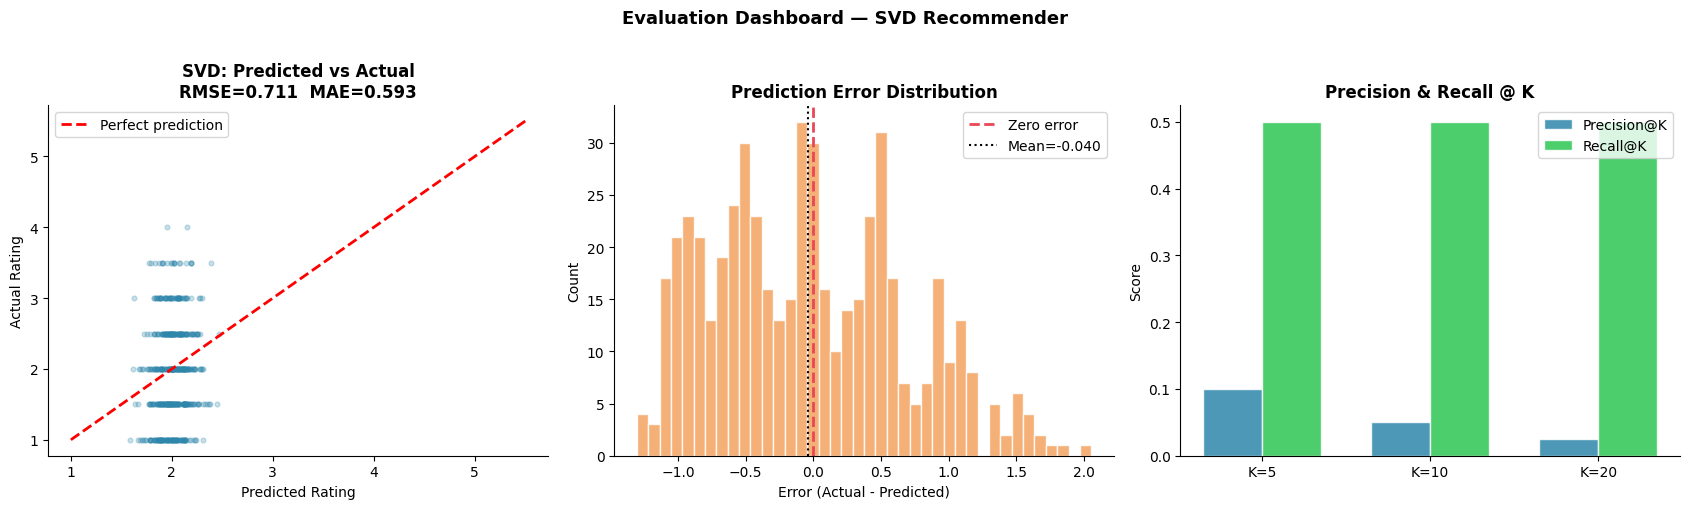

In [13]:
# Evaluation dashboard
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Actual vs predicted scatter
idx = np.random.choice(len(actuals), min(500, len(actuals)), replace=False)
axes[0].scatter(predictions[idx], actuals[idx], alpha=0.25, s=12, color=BLUE)
axes[0].plot([1, 5.5], [1, 5.5], "r--", lw=2, label="Perfect prediction")
axes[0].set_xlabel("Predicted Rating"); axes[0].set_ylabel("Actual Rating")
axes[0].set_title(f"SVD: Predicted vs Actual\nRMSE={rmse:.3f}  MAE={mae:.3f}",
                  fontweight="bold")
axes[0].legend()

# 2. Error distribution
errors = actuals - predictions
axes[1].hist(errors, bins=40, color=ORANGE, edgecolor="white", alpha=0.85)
axes[1].axvline(0, color=RED, lw=2, linestyle="--", label="Zero error")
axes[1].axvline(errors.mean(), color="black", lw=1.5, linestyle=":",
                label=f"Mean={errors.mean():.3f}")
axes[1].set_xlabel("Error (Actual - Predicted)"); axes[1].set_ylabel("Count")
axes[1].set_title("Prediction Error Distribution", fontweight="bold"); axes[1].legend()

# 3. Precision & Recall @ K
k_vals = [5, 10, 20]
pv, rv = [], []
for k in k_vals:
    precs, recs = [], []
    for uid in test_ratings["user_id"].unique():
        p, r = precision_recall_at_k(uid, k=k)
        if p is not None:
            precs.append(p); recs.append(r)
    pv.append(np.mean(precs)); rv.append(np.mean(recs))

x = np.arange(len(k_vals)); w = 0.35
axes[2].bar(x-w/2, pv, w, label="Precision@K", color=BLUE, edgecolor="white", alpha=0.85)
axes[2].bar(x+w/2, rv, w, label="Recall@K",    color=GREEN, edgecolor="white", alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels([f"K={k}" for k in k_vals])
axes[2].set_ylabel("Score"); axes[2].set_title("Precision & Recall @ K", fontweight="bold")
axes[2].legend()

plt.suptitle("Evaluation Dashboard — SVD Recommender", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/tmp/rs_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


---
#### Final Comparison — All Approaches Side by Side

In [14]:
print("=" * 65)
print(f"  RECOMMENDATION COMPARISON FOR USER {TARGET_USER}")
print("=" * 65)

already_rated = (user_item_matrix.loc[TARGET_USER].dropna()
                 .sort_values(ascending=False).reset_index())
already_rated.columns = ["movie_id","rating"]
already_rated = already_rated.merge(movies[["movie_id","title","genres"]], on="movie_id")
print(f"\nUser {TARGET_USER} top rated movies:")
print(already_rated.head(5)[["title","genres","rating"]].to_string(index=False))

approach_results = [
    ("User-Based CF",   user_recs,    "predicted_rating"),
    ("SVD",             svd_recs,     "predicted_rating"),
    ("Content-Based",   cb_user_recs, "content_score"),
    ("Hybrid",          hybrid_recs,  "hybrid_score"),
]
for name, df_r, col in approach_results:
    print(f"\n{name} (top 5):")
    if not df_r.empty:
        print(df_r[["title","genres"]].head(5).to_string(index=False))
    else:
        print("  No recommendations generated.")


  RECOMMENDATION COMPARISON FOR USER 5

User 5 top rated movies:
                      title                    genres  rating
Silence of the Lambs (1991)     Crime|Horror|Thriller     2.5
   The Grand Budapest Hotel        Comedy|Crime|Drama     2.5
        Finding Nemo (2003) Animation|Children|Comedy     2.5
           Star Wars (1977)   Action|Adventure|Sci-Fi     2.0
          Home Alone (1990)           Children|Comedy     1.5

User-Based CF (top 5):
                      title                          genres
Shawshank Redemption (1994)                     Crime|Drama
            Whiplash (2014)                     Drama|Music
          Get Shorty (1995)             Action|Comedy|Drama
        Pulp Fiction (1994)            Crime|Drama|Thriller
                  Up (2009) Animation|Children|Comedy|Drama

SVD (top 5):
                   title                   genres
Mad Max Fury Road (2015)  Action|Adventure|Sci-Fi
     Forrest Gump (1994) Comedy|Drama|Romance|War
    The Godfath

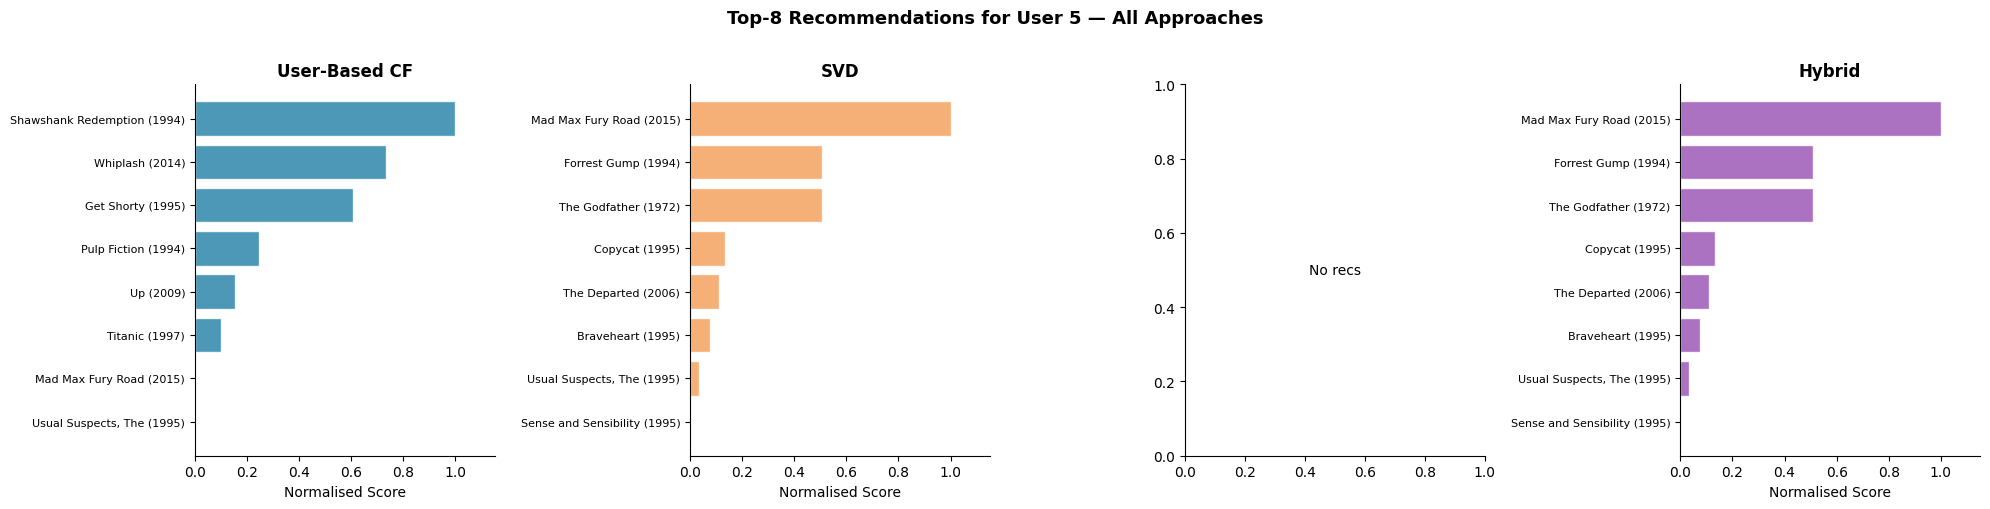

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
approach_plot = [
    ("User-Based CF",   user_recs,    "predicted_rating", BLUE),
    ("SVD",             svd_recs,     "predicted_rating", ORANGE),
    ("Content-Based",   cb_user_recs, "content_score",    GREEN),
    ("Hybrid",          hybrid_recs,  "hybrid_score",     PURPLE),
]
for ax, (name, df_r, score_col, color) in zip(axes, approach_plot):
    if df_r.empty:
        ax.text(0.5, 0.5, "No recs", ha="center", va="center", transform=ax.transAxes)
        continue
    top8 = df_r.head(8)
    sc   = MinMaxScaler().fit_transform(top8[[score_col]])[:, 0]
    ax.barh(range(len(top8)), sc[::-1], color=color, edgecolor="white", alpha=0.85)
    ax.set_yticks(range(len(top8)))
    ax.set_yticklabels([t[:28] for t in top8["title"].tolist()[::-1]], fontsize=8)
    ax.set_xlabel("Normalised Score"); ax.set_title(name, fontweight="bold")
    ax.set_xlim(0, 1.15)

plt.suptitle(f"Top-8 Recommendations for User {TARGET_USER} — All Approaches",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/tmp/rs_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


---
### Summary 

#### Approach Comparison

| | User-Based CF | Item-Based CF | SVD | Content-Based | Hybrid |
|---|---|---|---|---|---|
| **Cold-start: new user** | No | No | No | Partial | Partial |
| **Cold-start: new movie** | No | No | No | Yes | Partial |
| **Scalability** | Poor O(U²) | OK O(I²) | Good | Good | OK |
| **Interpretability** | High | High | Low | High | Medium |
| **Serendipity** | High | Medium | High | Low | High |
| **Used by** | Social apps | Amazon | Netflix | Pandora | Everyone |

### questionnaire

**Q: Why is sparsity a problem?**
Most users rate <1% of items. Sparse matrices make similarity noisy and SVD unstable. Solutions: regularisation, implicit feedback, smart fill strategies.

**Q: What is the cold-start problem?**
New users and items have no rating history. Content-based handles new movies. Onboarding questionnaires or demographic data handle new users.

**Q: Why did SVD win the Netflix Prize?**
It compresses the sparse rating matrix into dense latent factor vectors, finding hidden structure (genres, moods, eras) that generalises well to unseen pairs.

**Q: How do you evaluate in production?**
Offline metrics (RMSE, Precision@K) are proxies. Real evaluation requires A/B testing on user engagement: click-through rate, watch time, and return visits.

**Q: What would you add with more time?**
Implicit feedback (clicks, watch time), time-decay on old ratings, deep learning two-tower model, contextual bandits for exploration-exploitation balance.
